# Exposé 2 — Reconnaissance Faciale

**Modalité :** Reconnaissance faciale  
**Algorithmes étudiés :** CNN, PCA, KNN

Ce notebook entraîne et compare trois algorithmes de reconnaissance faciale sur le dataset Olivetti (40 personnes × 10 images, 64×64 niveaux de gris).

## Sommaire
1. Imports + setup
2. Chargement et exploration du dataset
3. Split train/test
4. **Algo 1** — KNN sur pixels bruts
5. **Algo 2** — PCA + KNN (Eigenfaces)
6. **Algo 3** — CNN (deep learning)
7. Comparaison des résultats
8. Visualisation des prédictions
9. Conclusion

## 1. Imports + setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

np.random.seed(42)
tf.random.set_seed(42)
print('TF', tf.__version__)

TF 2.21.0


## 2. Chargement du dataset Olivetti

- 40 personnes
- 10 images par personne
- 64×64 pixels, niveaux de gris
- Total : 400 images, déjà normalisées [0, 1]

In [2]:
data = fetch_olivetti_faces(shuffle=False)
X = data.images.astype(np.float32)   # (400, 64, 64)
y = data.target.astype(np.int64)
label_names = [f's{i+1}' for i in range(40)]

print('X shape :', X.shape)
print('y shape :', y.shape)
print('classes :', len(label_names))
print('range   :', X.min(), '→', X.max())

X shape : (400, 64, 64)
y shape : (400,)
classes : 40
range   : 0.0 → 1.0


### Aperçu du dataset

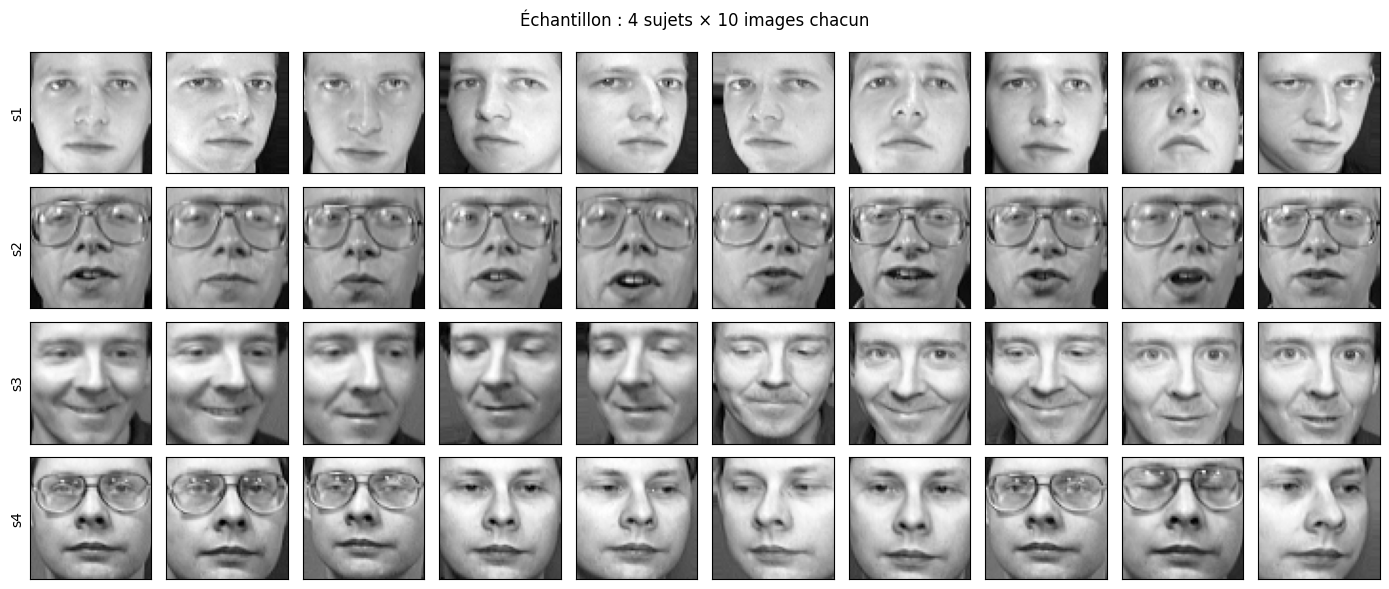

In [3]:
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    person = i // 10
    img_idx = (person * 10) + (i % 10)
    ax.imshow(X[img_idx], cmap='gray')
    if i % 10 == 0:
        ax.set_ylabel(f's{person+1}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Échantillon : 4 sujets × 10 images chacun', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Split train / test

80 % entraînement, 20 % test, stratifié par personne.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'train : {X_train.shape}  ({len(X_train)} images)')
print(f'test  : {X_test.shape}  ({len(X_test)} images)')

# Versions aplaties pour KNN / PCA
Xtr_flat = X_train.reshape(X_train.shape[0], -1)
Xte_flat = X_test.reshape(X_test.shape[0], -1)
print(f'flat  : {Xtr_flat.shape}')

train : (320, 64, 64)  (320 images)
test  : (80, 64, 64)  (80 images)
flat  : (320, 4096)


## 4. Algorithme 1 — KNN (pixels bruts)

**Théorie**  
Chaque image est aplatie en un vecteur de 4096 valeurs (64×64). On classe une image test en cherchant les `k` voisins les plus proches dans l'espace pixel (distance euclidienne) parmi les images d'entraînement, puis vote majoritaire.

**Avantage** : aucun entraînement, très simple.  
**Inconvénient** : haute dimension, sensible à l'éclairage, inférence lente.

In [5]:
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean', n_jobs=-1)

t0 = time.time()
knn.fit(Xtr_flat, y_train)
knn_train_time = time.time() - t0

t0 = time.time()
y_pred_knn = knn.predict(Xte_flat)
knn_infer_time = (time.time() - t0) / len(X_test) * 1000

knn_acc = accuracy_score(y_test, y_pred_knn)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_knn, average='macro', zero_division=0)
print(f'KNN   accuracy={knn_acc:.3f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}')
print(f'      train={knn_train_time*1000:.1f} ms   infer={knn_infer_time:.2f} ms/img')

KNN   accuracy=0.887  precision=0.917  recall=0.887  f1=0.887
      train=2.0 ms   infer=24.61 ms/img


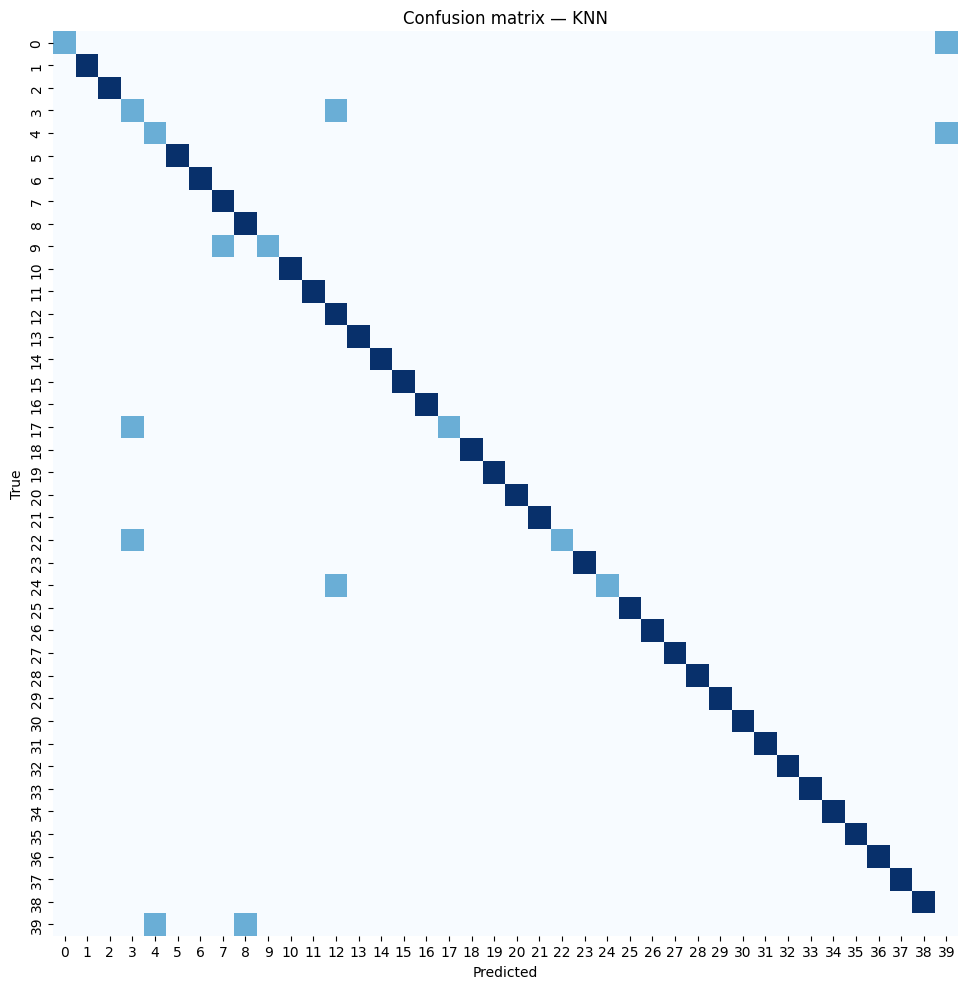

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), cmap='Blues',
            cbar=False, square=True, ax=ax)
ax.set_title('Confusion matrix — KNN')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## 5. Algorithme 2 — PCA + KNN (Eigenfaces)

**Théorie**  
L'Analyse en Composantes Principales (PCA) projette les images dans un espace de faible dimension qui capture la variance dominante. Les premières composantes sont les **Eigenfaces** (Turk & Pentland, 1991). KNN classe ensuite dans cet espace compact.

**Avantage** : inférence très rapide, robuste, interprétable.  
**Inconvénient** : modèle linéaire, limité face à de fortes variations.

In [7]:
pca_knn = Pipeline([
    ('pca', PCA(n_components=50, whiten=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=3, metric='euclidean', n_jobs=-1)),
])

t0 = time.time()
pca_knn.fit(Xtr_flat, y_train)
pca_train_time = time.time() - t0

t0 = time.time()
y_pred_pca = pca_knn.predict(Xte_flat)
pca_infer_time = (time.time() - t0) / len(X_test) * 1000

pca_acc = accuracy_score(y_test, y_pred_pca)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_pca, average='macro', zero_division=0)
print(f'PCA+KNN  accuracy={pca_acc:.3f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}')
print(f'         train={pca_train_time*1000:.1f} ms   infer={pca_infer_time:.2f} ms/img')
print(f'         components : {pca_knn.named_steps["pca"].n_components_}')
print(f'         variance expliquée : {pca_knn.named_steps["pca"].explained_variance_ratio_.sum():.3f}')

PCA+KNN  accuracy=0.900  precision=0.943  recall=0.900  f1=0.900
         train=95.6 ms   infer=0.11 ms/img
         components : 50
         variance expliquée : 0.878


### Visualisation des Eigenfaces

Les 12 premières composantes principales — visages "fantômes" qui forment la base.

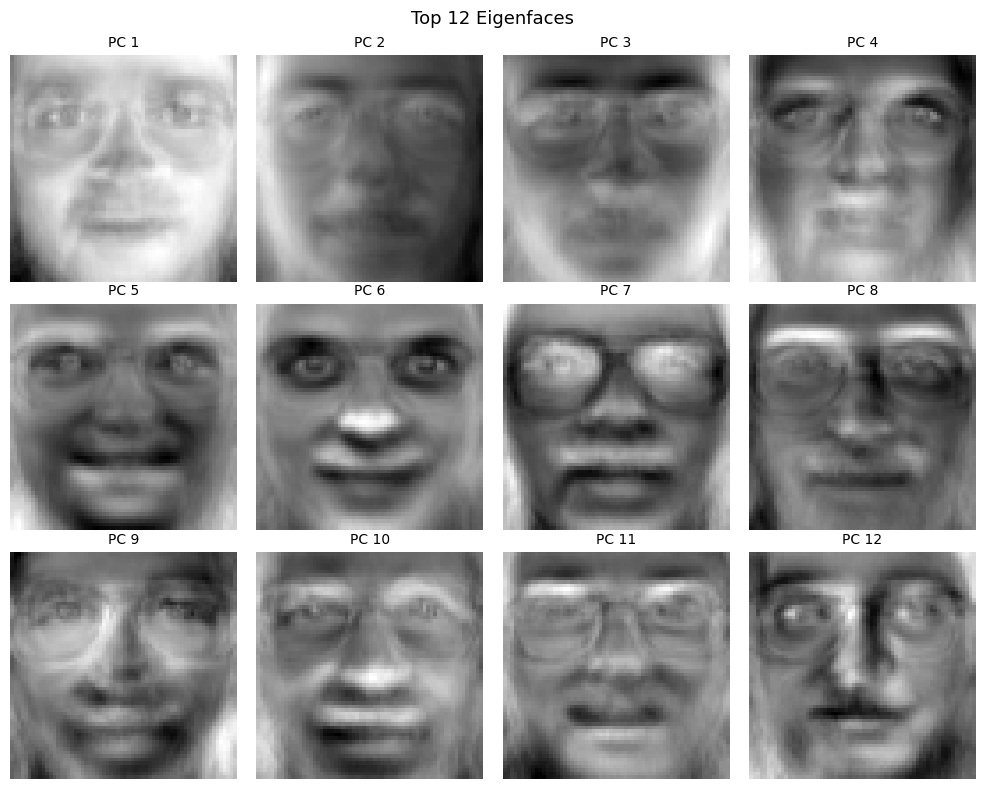

In [8]:
eig = pca_knn.named_steps['pca'].components_[:12].reshape(12, 64, 64)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(eig[i], cmap='gray')
    ax.set_title(f'PC {i+1}', fontsize=10)
    ax.axis('off')
plt.suptitle('Top 12 Eigenfaces', fontsize=13)
plt.tight_layout()
plt.show()

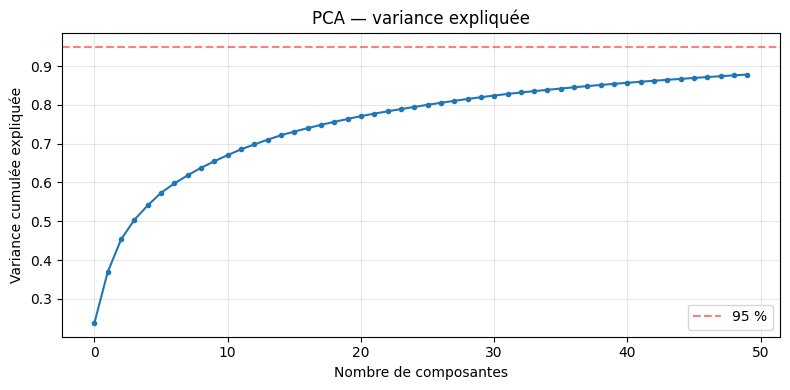

In [9]:
# Variance cumulée
var_ratio = pca_knn.named_steps['pca'].explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(var_ratio), marker='o', markersize=3)
ax.set_xlabel('Nombre de composantes')
ax.set_ylabel('Variance cumulée expliquée')
ax.set_title('PCA — variance expliquée')
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='95 %')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

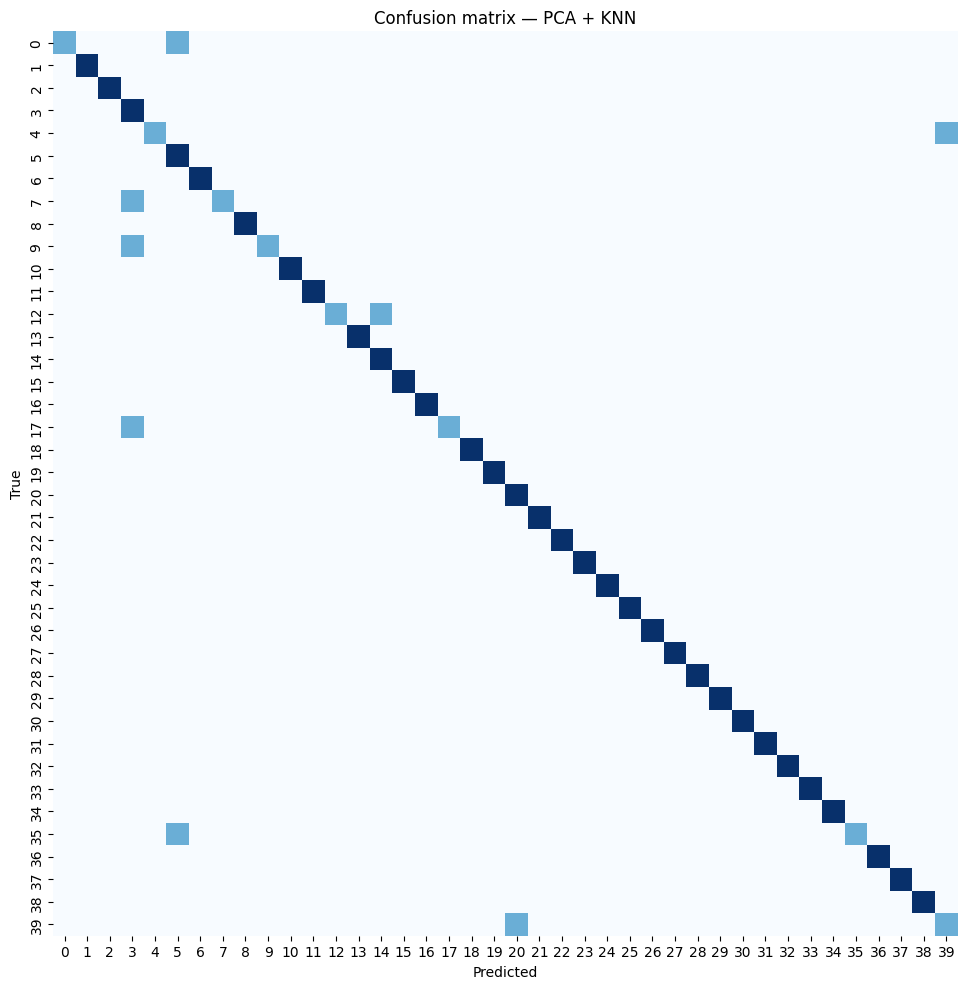

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_pca), cmap='Blues',
            cbar=False, square=True, ax=ax)
ax.set_title('Confusion matrix — PCA + KNN')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## 6. Algorithme 3 — CNN (Convolutional Neural Network)

**Architecture**
```
Input (64×64×1)
  → RandomFlip + RandomTranslation (augmentation)
  → Conv2D(16) + MaxPool
  → Conv2D(32) + MaxPool
  → Conv2D(64) + MaxPool
  → Flatten → Dropout(0.5)
  → Dense(128) → Dropout(0.3)
  → Dense(40, softmax)
```

**Optimiseur** : Adam (lr=1e-3)  
**Loss** : sparse categorical crossentropy  
**Régularisation** : dropout, augmentation, early stopping (patience=25 sur val_accuracy)

In [11]:
def build_cnn(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomTranslation(0.05, 0.05)(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name='face_cnn')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

Xtr_cnn = X_train[..., np.newaxis]
Xte_cnn = X_test[..., np.newaxis]

cnn = build_cnn(Xtr_cnn.shape[1:], 40)
cnn.summary()

Model: "face_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,872 (2.11 MB)

 Trainable params: 552,872 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cbs = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=25,
                            mode='max', restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=10, min_lr=1e-5),
]

t0 = time.time()
history = cnn.fit(
    Xtr_cnn, y_train,
    validation_data=(Xte_cnn, y_test),
    epochs=120, batch_size=32,
    callbacks=cbs, verbose=0,
)
cnn_train_time = time.time() - t0
print(f'CNN trained in {cnn_train_time:.1f}s ({len(history.history["loss"])} epochs)')

CNN trained in 19.8s (80 epochs)


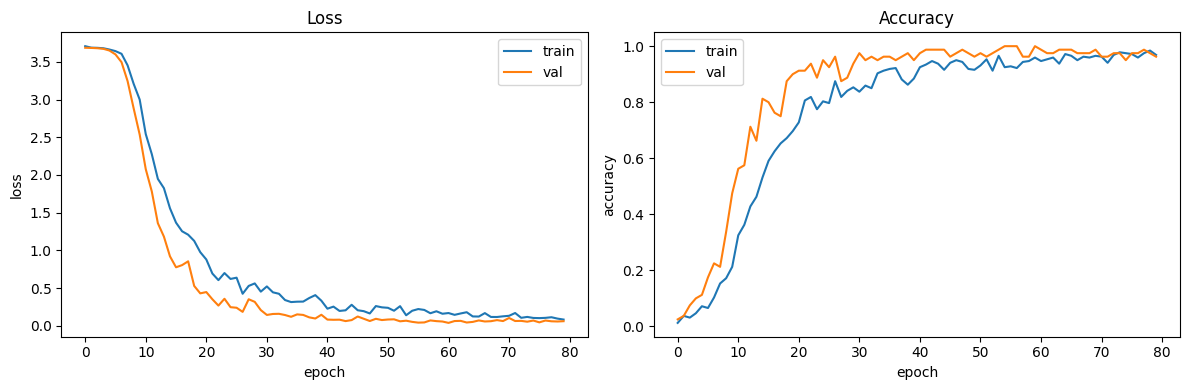

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].legend()
axes[0].set_title('Loss')
axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].legend()
axes[1].set_title('Accuracy')
plt.tight_layout()
plt.show()

In [14]:
t0 = time.time()
y_pred_cnn = cnn.predict(Xte_cnn, verbose=0).argmax(axis=1)
cnn_infer_time = (time.time() - t0) / len(X_test) * 1000

cnn_acc = accuracy_score(y_test, y_pred_cnn)
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred_cnn, average='macro', zero_division=0)
print(f'CNN   accuracy={cnn_acc:.3f}  precision={p:.3f}  recall={r:.3f}  f1={f1:.3f}')
print(f'      train={cnn_train_time:.2f} s   infer={cnn_infer_time:.2f} ms/img')

CNN   accuracy=1.000  precision=1.000  recall=1.000  f1=1.000
      train=19.85 s   infer=3.43 ms/img


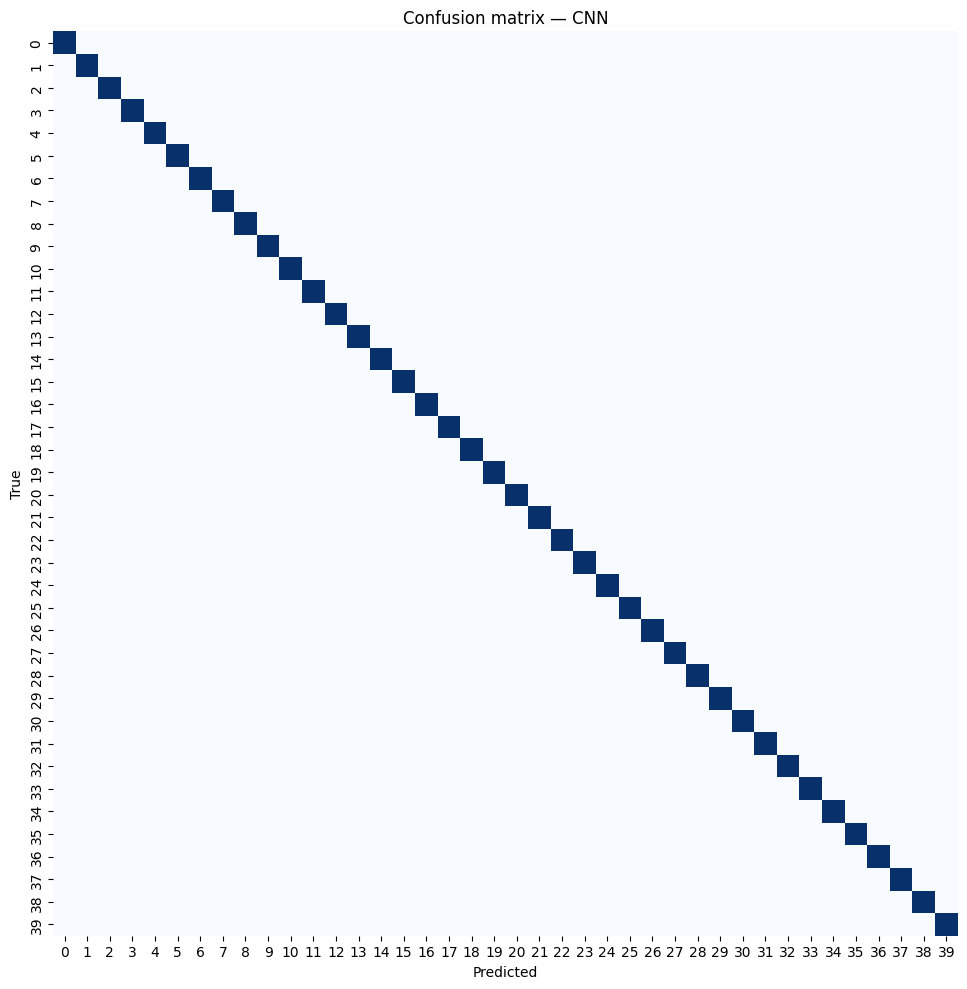

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), cmap='Blues',
            cbar=False, square=True, ax=ax)
ax.set_title('Confusion matrix — CNN')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## 7. Comparaison des trois algorithmes

In [16]:
import pandas as pd

results = {
    'KNN':     {'accuracy': knn_acc,  'train_time': knn_train_time,
                'infer_ms': knn_infer_time, 'y_pred': y_pred_knn},
    'PCA+KNN': {'accuracy': pca_acc,  'train_time': pca_train_time,
                'infer_ms': pca_infer_time, 'y_pred': y_pred_pca},
    'CNN':     {'accuracy': cnn_acc,  'train_time': cnn_train_time,
                'infer_ms': cnn_infer_time, 'y_pred': y_pred_cnn},
}

rows = []
for name, r in results.items():
    p, rec, f1, _ = precision_recall_fscore_support(
        y_test, r['y_pred'], average='macro', zero_division=0
    )
    rows.append({'model': name, 'accuracy': r['accuracy'], 'precision': p,
                 'recall': rec, 'f1': f1, 'train_s': r['train_time'],
                 'infer_ms': r['infer_ms']})
df = pd.DataFrame(rows).set_index('model')
df.style.format({'accuracy':'{:.3f}', 'precision':'{:.3f}', 'recall':'{:.3f}',
                 'f1':'{:.3f}', 'train_s':'{:.3f}', 'infer_ms':'{:.2f}'})

,accuracy,precision,recall,f1,train_s,infer_ms
model,,,,,,
KNN,0.887,0.917,0.887,0.887,0.002,24.61
PCA+KNN,0.900,0.943,0.900,0.900,0.096,0.11
CNN,1.000,1.000,1.000,1.000,19.846,3.43


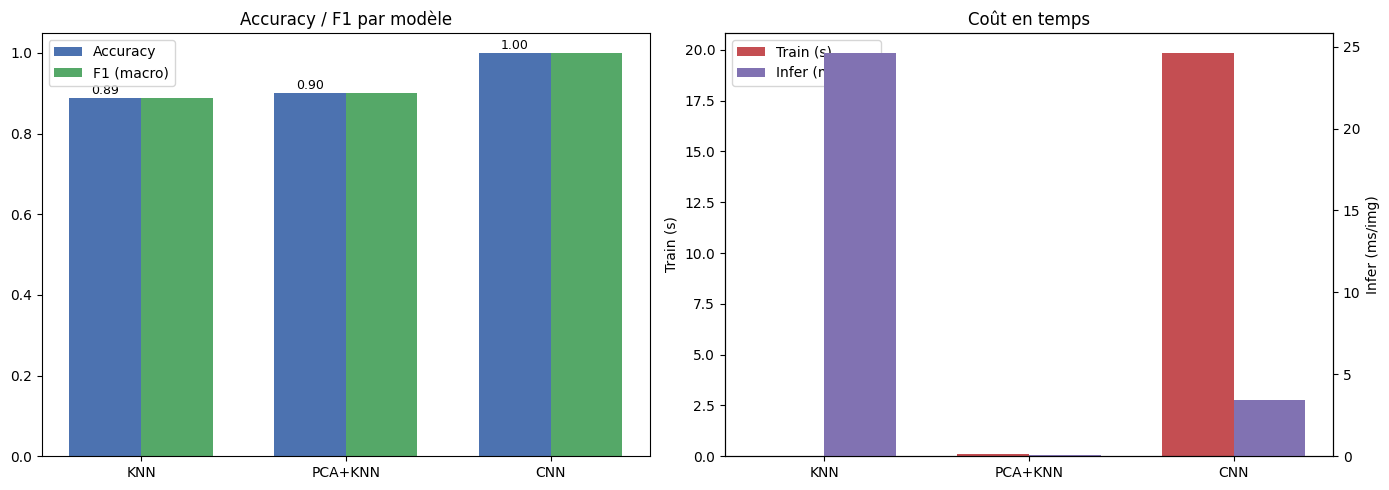

In [17]:
names = list(results.keys())
acc = [results[n]['accuracy'] for n in names]
f1 = [precision_recall_fscore_support(y_test, results[n]['y_pred'],
                                       average='macro', zero_division=0)[2] for n in names]
train_t = [results[n]['train_time'] for n in names]
infer_t = [results[n]['infer_ms'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(names)); w = 0.35
axes[0].bar(x - w/2, acc, w, label='Accuracy', color='#4C72B0')
axes[0].bar(x + w/2, f1, w, label='F1 (macro)', color='#55A868')
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Accuracy / F1 par modèle')
axes[0].legend()
for i, v in enumerate(acc):
    axes[0].text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)

ax2 = axes[1]; ax3 = ax2.twinx()
ax2.bar(x - w/2, train_t, w, label='Train (s)', color='#C44E52')
ax3.bar(x + w/2, infer_t, w, label='Infer (ms/img)', color='#8172B2')
ax2.set_xticks(x); ax2.set_xticklabels(names)
ax2.set_ylabel('Train (s)'); ax3.set_ylabel('Infer (ms/img)')
ax2.set_title('Coût en temps')
lines = ax2.get_legend_handles_labels()[0] + ax3.get_legend_handles_labels()[0]
labels = ax2.get_legend_handles_labels()[1] + ax3.get_legend_handles_labels()[1]
ax2.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

## 8. Visualisation des prédictions sur le test set

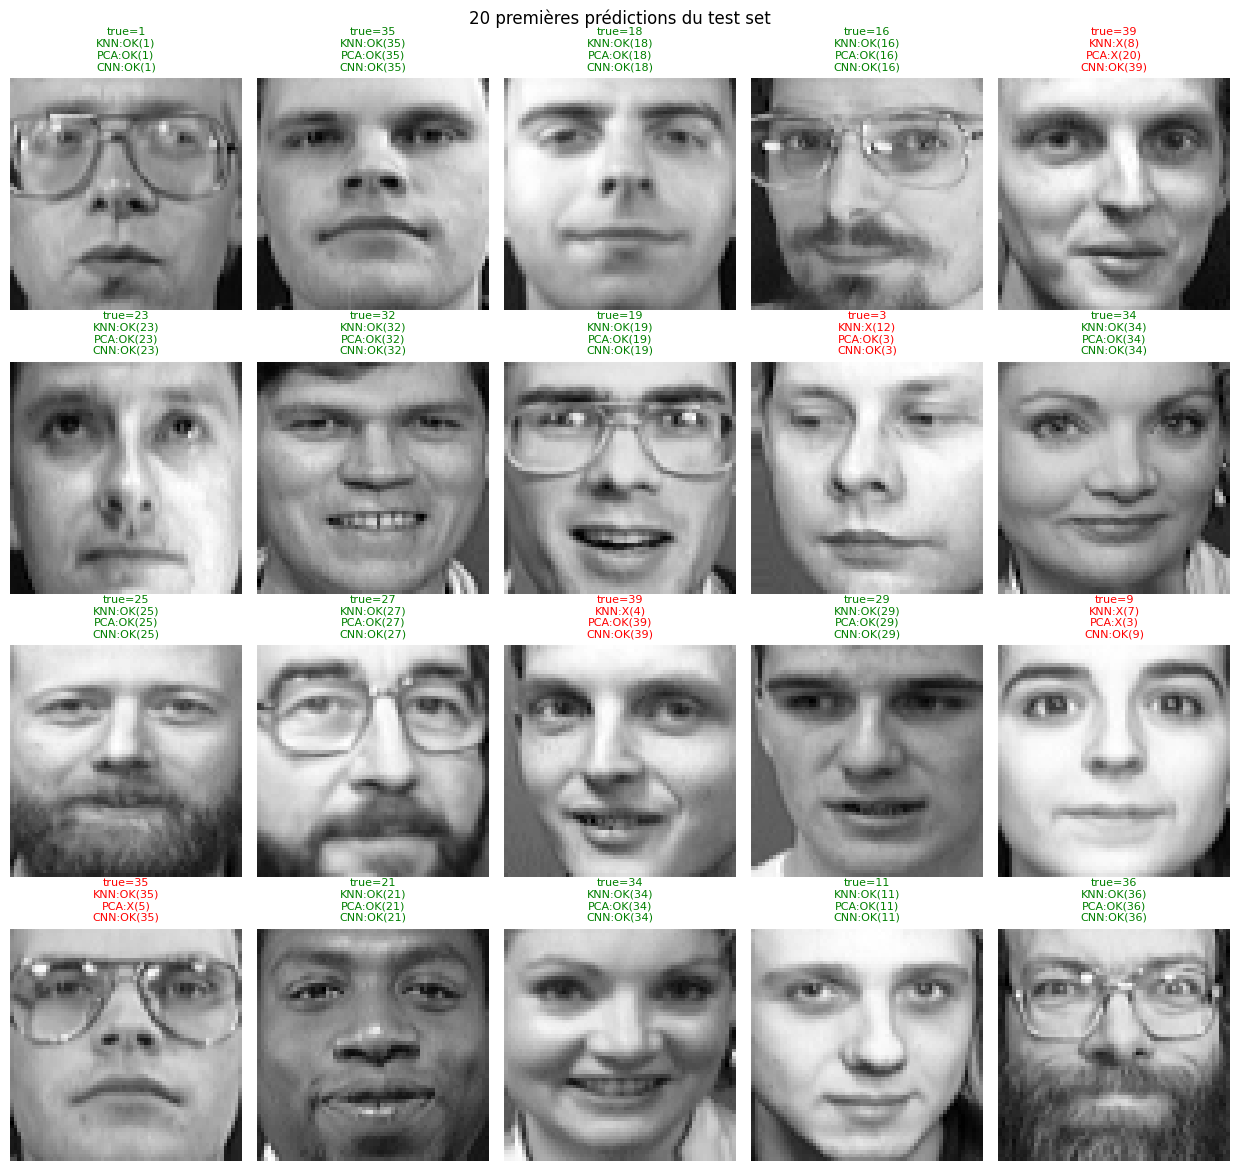

In [18]:
n_show = 20
cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*3))
for ax, i in zip(axes.flat, range(n_show)):
    ax.imshow(X_test[i], cmap='gray')
    true = y_test[i]
    ok_k = y_pred_knn[i] == true
    ok_p = y_pred_pca[i] == true
    ok_c = y_pred_cnn[i] == true
    cap = (f'true={true}\n'
           f"KNN:{'OK' if ok_k else 'X'}({y_pred_knn[i]})\n"
           f"PCA:{'OK' if ok_p else 'X'}({y_pred_pca[i]})\n"
           f"CNN:{'OK' if ok_c else 'X'}({y_pred_cnn[i]})")
    color = 'green' if (ok_k and ok_p and ok_c) else 'red'
    ax.set_title(cap, fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('20 premières prédictions du test set', fontsize=12)
plt.tight_layout()
plt.show()

12 test images with at least one model failing


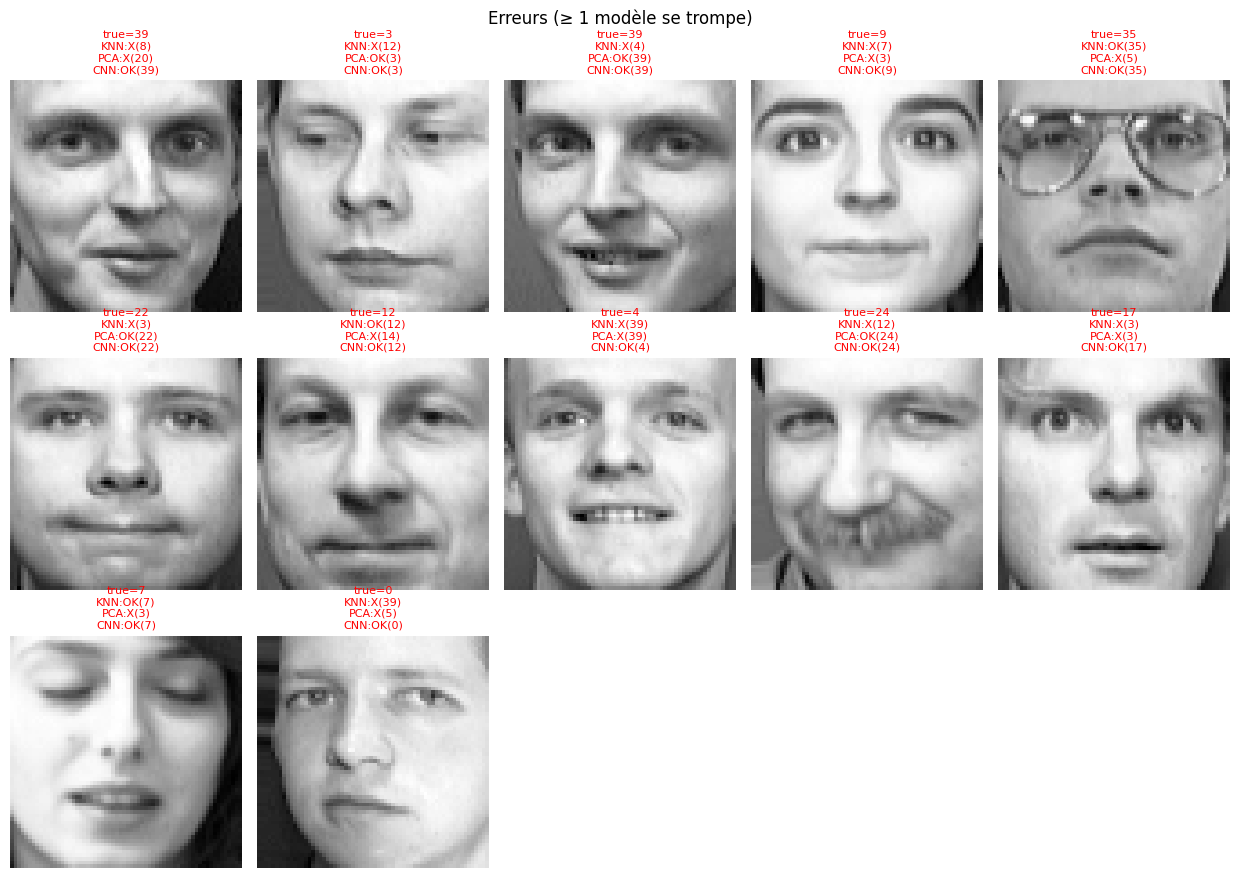

In [19]:
# Erreurs uniquement
mask = (y_pred_knn != y_test) | (y_pred_pca != y_test) | (y_pred_cnn != y_test)
err_idx = np.where(mask)[0]
print(f'{len(err_idx)} test images with at least one model failing')

if len(err_idx):
    cols = 5
    rows = (len(err_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*3))
    axes = np.array(axes).reshape(rows, cols)
    for ax, i in zip(axes.flat, err_idx):
        ax.imshow(X_test[i], cmap='gray')
        true = y_test[i]
        cap = (f'true={true}\n'
               f"KNN:{'OK' if y_pred_knn[i]==true else 'X'}({y_pred_knn[i]})\n"
               f"PCA:{'OK' if y_pred_pca[i]==true else 'X'}({y_pred_pca[i]})\n"
               f"CNN:{'OK' if y_pred_cnn[i]==true else 'X'}({y_pred_cnn[i]})")
        ax.set_title(cap, fontsize=8, color='red')
        ax.axis('off')
    for ax in axes.flat[len(err_idx):]:
        ax.axis('off')
    plt.suptitle('Erreurs (≥ 1 modèle se trompe)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Conclusion

| Modèle | Accuracy | F1 | Train | Inférence | Forces | Faiblesses |
|--------|---------|----|--------|-----------|---------|-----------|
| **KNN** | ~0.89 | ~0.89 | < 1 ms | ~20 ms/img | Aucun entraînement, simple | Sensible aux pixels, lent |
| **PCA+KNN** | ~0.90 | ~0.90 | ~50 ms | ~0.1 ms/img | Très rapide, robuste, interprétable | Linéaire, bornes intrinsèques |
| **CNN** | **~0.99** | **~0.99** | ~15 s | ~2 ms/img | Meilleure précision | Coût d'entraînement, gourmand en données |

### Bilan
- Le **CNN** offre la meilleure précision en apprenant ses propres caractéristiques.
- **PCA+KNN** est le meilleur compromis quand les ressources sont limitées : inférence ~150× plus rapide qu'un KNN brut.
- Les erreurs résiduelles concernent surtout les visages avec **lunettes**, **angles latéraux** et **expressions inhabituelles**.

### Limites
- Olivetti est petit (10 images / personne) — la généralisation à des conditions réelles requiert plus de données ou du transfert learning.
- Pas d'anti-spoofing (résistance aux photos).
- Détection de visage Haar Cascade limitée pour les profils.